# Introduction to pandas

## Learning Objectives
- Import the Pandas library and understand when to use it over NumPy.
- Use Pandas to load a CSV data set.
- Get basic information about a Pandas DataFrame using `info()`, `describe()`, `columns`, and `T`.
- Set a column as the row index using `DataFrame.set_index`.
- Select individual values from a DataFrame using `iloc` (by position) and `loc` (by label).
- Select a subset of both rows and columns from a DataFrame in a single operation.
- Select a subset of a DataFrame by a single Boolean criterion (masking).
- Make quick plots directly from a DataFrame using `DataFrame.plot()`.
- Understand Python dictionaries and how to iterate over their keys.
- Create a DataFrame from a dictionary.
- Combine multiple DataFrames using `pd.concat`.
- Save a DataFrame to a CSV file using `DataFrame.to_csv`.

## Using the Pandas library to do statistics on tabular data

[Pandas](http://pandas.pydata.org/) is a an open source library providing high-performance, easy-to-use data structures and data analysis tools. Pandas is particularly suited to the analysis of tabular data, i.e. data that can can go into a table. In other words, if you can imagine the data in an Excel spreadsheet, then Pandas is the tool for the job.

- Pandas is a widely-used Python library for statistics, particularly on tabular data.
- Borrows many features from R’s dataframes.
    - A 2-dimensional table whose columns have names and potentially have different data types.
- Load it with import pandas as pd. The alias pd is commonly used for Pandas.
- Read a Comma Separated Values (CSV) data file with pd.read_csv.
    - Argument is the name of the file to be read.
    - Assign result to a variable to store the data that was read.
    
In this lecture, we will go over the basic capabilities of Pandas. It is a very deep library, and you will need to dig into the [documentation](http://pandas.pydata.org/pandas-docs/stable/) for more advanced usage.

In [1]:
import numpy as np
import pandas as pd

### Reading data into a pandas dataframe
Lets use pandas to read one of our well-log data files

In [2]:
path = '/mnt/c/Ryan_Data/Teaching/work/classes/GPGN268/coursework-du/ds01-well-log/data/iodp-logging-data/EXP372/U1517A/372-U1517A_res-phase-nscope.csv'
df = pd.read_csv(path)

ParserError: Error tokenizing data. C error: Expected 2 fields in line 5, saw 16


We see that the pandas printed things into a table but there is something weird about it. It seem like the first couple of lines have a different format. Let's use the terminal to look at the data file. Open a new terminal window from Jupyter Lab and navigate to the data folder

```
cd ~/work/classes/GPGN268/coursework-villasboas/ds01-well-log/data/iodp-logging-data/EXP372/U1517A
cat 372-U1517A_cali-nscope.csv | head
```


In [3]:
df = pd.read_csv(path, skiprows=[0, 1, 2, 3, 5])

In [4]:
df

,DEPTH_LSF,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
0,0.1348,0.609138,0.606420,0.609138,0.625390,0.628182,0.625390,0.633311,0.642043,0.633311,0.635440,0.646374,0.635440,0.640069,0.650177,0.640069
1,0.2872,0.627580,0.606823,0.627579,0.646545,0.632340,0.646545,0.654598,0.649771,0.654598,0.654733,0.655505,0.654733,0.657815,0.659040,0.657815
2,0.4396,0.644199,0.610627,0.644199,0.663118,0.632921,0.663118,0.674138,0.650050,0.674138,0.678495,0.658393,0.678495,0.684064,0.664154,0.684064
3,0.5920,0.663892,0.619708,0.663892,0.681017,0.637017,0.681017,0.693011,0.653297,0.693011,0.699174,0.662530,0.699174,0.704357,0.666172,0.704357
4,0.7444,0.682845,0.630840,0.682845,0.697899,0.645322,0.697899,0.709838,0.659337,0.709838,0.717195,0.668764,0.717195,0.722439,0.674389,0.722439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221,186.2152,1.349504,1.321876,1.365414,1.367666,1.349495,1.378745,1.385877,1.375210,1.392777,1.399951,1.391715,1.405571,1.409557,1.401155,1.415531
1222,186.3676,1.307980,1.264115,1.329541,1.327183,1.286108,1.349225,1.350870,1.316730,1.371008,1.374388,1.345850,1.392854,1.392158,1.364525,1.411478
1223,186.5200,1.283353,1.242980,1.300715,1.326024,1.298547,1.340192,1.358904,1.344285,1.367395,1.381087,1.372510,1.386490,1.402996,1.395565,1.408120
1224,186.6724,1.253862,1.187660,1.279550,1.308796,1.272658,1.326299,1.348609,1.325449,1.361735,1.371802,1.356053,1.381517,1.399445,1.405782,1.395303


Now, we read our data using pandas, but what type of object `df` is?

In [5]:
type(df)

pandas.DataFrame

Before we were using `numpy` to read data into numpy arrays. With pandas, our data is stored as a pandas DataFrame.

### `pandas.DataFrame.set_index` 
- It specifies a column’s values should be used as row headings
- Now, we see that the row labels are currently numbers (1-1226), but we would really want the depths to be the row labels. We can use

In [6]:
df.set_index('DEPTH_LSF', inplace=True)
df

,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
DEPTH_LSF,,,,,,,,,,,,,,,
0.1348,0.609138,0.606420,0.609138,0.625390,0.628182,0.625390,0.633311,0.642043,0.633311,0.635440,0.646374,0.635440,0.640069,0.650177,0.640069
0.2872,0.627580,0.606823,0.627579,0.646545,0.632340,0.646545,0.654598,0.649771,0.654598,0.654733,0.655505,0.654733,0.657815,0.659040,0.657815
0.4396,0.644199,0.610627,0.644199,0.663118,0.632921,0.663118,0.674138,0.650050,0.674138,0.678495,0.658393,0.678495,0.684064,0.664154,0.684064
0.5920,0.663892,0.619708,0.663892,0.681017,0.637017,0.681017,0.693011,0.653297,0.693011,0.699174,0.662530,0.699174,0.704357,0.666172,0.704357
0.7444,0.682845,0.630840,0.682845,0.697899,0.645322,0.697899,0.709838,0.659337,0.709838,0.717195,0.668764,0.717195,0.722439,0.674389,0.722439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186.2152,1.349504,1.321876,1.365414,1.367666,1.349495,1.378745,1.385877,1.375210,1.392777,1.399951,1.391715,1.405571,1.409557,1.401155,1.415531
186.3676,1.307980,1.264115,1.329541,1.327183,1.286108,1.349225,1.350870,1.316730,1.371008,1.374388,1.345850,1.392854,1.392158,1.364525,1.411478
186.5200,1.283353,1.242980,1.300715,1.326024,1.298547,1.340192,1.358904,1.344285,1.367395,1.381087,1.372510,1.386490,1.402996,1.395565,1.408120


### `pandas.DataFrame.head()` and `tail()`
- Use pandas.DataFrame.head() to show the first few rows of the DataFrame
- You can also specify the number of rows with `df.head(10)`

In [7]:
df.head()

,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
DEPTH_LSF,,,,,,,,,,,,,,,
0.1348,0.609138,0.606420,0.609138,0.625390,0.628182,0.625390,0.633311,0.642043,0.633311,0.635440,0.646374,0.635440,0.640069,0.650177,0.640069
0.2872,0.627580,0.606823,0.627579,0.646545,0.632340,0.646545,0.654598,0.649771,0.654598,0.654733,0.655505,0.654733,0.657815,0.659040,0.657815
0.4396,0.644199,0.610627,0.644199,0.663118,0.632921,0.663118,0.674138,0.650050,0.674138,0.678495,0.658393,0.678495,0.684064,0.664154,0.684064
0.5920,0.663892,0.619708,0.663892,0.681017,0.637017,0.681017,0.693011,0.653297,0.693011,0.699174,0.662530,0.699174,0.704357,0.666172,0.704357
0.7444,0.682845,0.630840,0.682845,0.697899,0.645322,0.697899,0.709838,0.659337,0.709838,0.717195,0.668764,0.717195,0.722439,0.674389,0.722439


- You can also specify the number of rows with `df.tail(10)`

In [8]:
df.tail()

,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
DEPTH_LSF,,,,,,,,,,,,,,,
186.2152,1.349504,1.321876,1.365414,1.367666,1.349495,1.378745,1.385877,1.375210,1.392777,1.399951,1.391715,1.405571,1.409557,1.401155,1.415531
186.3676,1.307980,1.264115,1.329541,1.327183,1.286108,1.349225,1.350870,1.316730,1.371008,1.374388,1.345850,1.392854,1.392158,1.364525,1.411478
186.5200,1.283353,1.242980,1.300715,1.326024,1.298547,1.340192,1.358904,1.344285,1.367395,1.381087,1.372510,1.386490,1.402996,1.395565,1.408120
186.6724,1.253862,1.187660,1.279550,1.308796,1.272658,1.326299,1.348609,1.325449,1.361735,1.371802,1.356053,1.381517,1.399445,1.405782,1.395303
186.8248,1.253858,1.187652,1.279547,1.308793,1.272654,1.326297,1.348608,1.325446,1.361734,1.371801,1.356050,1.381517,1.399445,1.405784,1.395301


### `DataFrame.info()` 
- to find out more about a dataframe.

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1226 entries, 0.1348 to 186.8248
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P16B    1226 non-null   float64
 1   P16H    1226 non-null   float64
 2   P16L    1226 non-null   float64
 3   P22B    1226 non-null   float64
 4   P22H    1226 non-null   float64
 5   P22L    1226 non-null   float64
 6   P28B    1226 non-null   float64
 7   P28H    1226 non-null   float64
 8   P28L    1226 non-null   float64
 9   P34B    1226 non-null   float64
 10  P34H    1226 non-null   float64
 11  P34L    1226 non-null   float64
 12  P40B    1226 non-null   float64
 13  P40H    1226 non-null   float64
 14  P40L    1226 non-null   float64
dtypes: float64(15)
memory usage: 153.2 KB


Here is the information given to us
- This is a DataFrame
- There are 1226 rows with values from 0.1348 to 186.8248
- There are fourteen columns, each of which has two actual 64-bit floating point values.
- We will talk later about null values, which are used to represent missing observations.
- Uses 153.2 KB of memory.

### `DataFrame.columns`
- Is a variable that stores information about the dataframe’s columns
- Note that this is data, not a method (It doesn’t have parentheses), so do not use () to try to call it.

In [10]:
df.columns

Index(['P16B', 'P16H', 'P16L', 'P22B', 'P22H', 'P22L', 'P28B', 'P28H', 'P28L',
       'P34B', 'P34H', 'P34L', 'P40B', 'P40H', 'P40L'],
      dtype='str')

### `DataFrame.T` transpose a DataFrame

- Sometimes want to treat columns as rows and vice versa.
- Transpose (written .T) doesn’t copy the data, just changes the program’s view of it.
- Like columns, it is a member variable.

In [11]:
df.T

DEPTH_LSF,0.1348,0.2872,0.4396,0.5920,0.7444,0.8968,1.0492,1.2016,1.3540,1.5064,...,185.4532,185.6056,185.7580,185.9104,186.0628,186.2152,186.3676,186.5200,186.6724,186.8248
P16B,0.609138,0.627580,0.644199,0.663892,0.682845,0.731617,0.761301,0.804455,0.844715,0.910954,...,1.310211,1.308250,1.291665,1.339404,1.295607,1.349504,1.307980,1.283353,1.253862,1.253858
P16H,0.606420,0.606823,0.610627,0.619708,0.630840,0.694116,0.738197,0.792348,0.848850,0.908871,...,1.253256,1.230254,1.216608,1.269162,1.238327,1.321876,1.264115,1.242980,1.187660,1.187652
P16L,0.609138,0.627579,0.644199,0.663892,0.682845,0.731617,0.761301,0.804454,0.844715,0.910954,...,1.339484,1.350304,1.328359,1.383009,1.322925,1.365414,1.329541,1.300715,1.279550,1.279547
P22B,0.625390,0.646545,0.663118,0.681017,0.697899,0.745441,0.776537,0.815348,0.853703,0.915684,...,1.348680,1.361344,1.338605,1.370615,1.322849,1.367666,1.327183,1.326024,1.308796,1.308793
P22H,0.628182,0.632340,0.632921,0.637017,0.645322,0.712391,0.751259,0.798334,0.856051,0.914294,...,1.309219,1.305284,1.281755,1.313840,1.272447,1.349495,1.286108,1.298547,1.272658,1.272654
P22L,0.625390,0.646545,0.663118,0.681017,0.697899,0.745441,0.776537,0.815348,0.853703,0.915684,...,1.372062,1.398481,1.372327,1.410082,1.349988,1.378745,1.349225,1.340192,1.326299,1.326297
P28B,0.633311,0.654598,0.674138,0.693011,0.709838,0.756381,0.789001,0.826379,0.864378,0.925173,...,1.372776,1.396027,1.369928,1.401347,1.347189,1.385877,1.350870,1.358904,1.348609,1.348608
P28H,0.642043,0.649771,0.650050,0.653297,0.659337,0.728494,0.762553,0.808085,0.865635,0.923758,...,1.340607,1.359139,1.324898,1.364223,1.300720,1.375210,1.316730,1.344285,1.325449,1.325446
P28L,0.633311,0.654598,0.674138,0.693011,0.709838,0.756381,0.789000,0.826378,0.864378,0.925173,...,1.393662,1.423079,1.399942,1.429269,1.375080,1.392777,1.371008,1.367395,1.361735,1.361734
P34B,0.635440,0.654733,0.678495,0.699174,0.717195,0.762395,0.795984,0.832787,0.871146,0.933119,...,1.385789,1.411744,1.384295,1.417707,1.362655,1.399951,1.374388,1.381087,1.371802,1.371801


### `DataFrame.describe()` give summary statistics about data

DataFrame.describe() gets the summary statistics of only the columns that have numerical data. All other columns are ignored, unless you use the argument include='all'.

In [12]:
df.describe()

,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
count,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000,1226.000000
mean,1.341873,1.303217,1.356043,1.373337,1.339729,1.387603,1.400060,1.371811,1.413030,1.418855,1.393411,1.431126,1.436270,1.412525,1.448081
std,0.223072,0.258176,0.224783,0.213214,0.245582,0.213473,0.206943,0.236748,0.205067,0.202675,0.231264,0.199095,0.201042,0.229986,0.195603
min,0.249499,0.229939,0.249499,0.264302,0.234238,0.264302,0.279298,0.261545,0.279298,0.291382,0.269856,0.291382,0.301117,0.264072,0.301117
25%,1.271618,1.240749,1.285699,1.297918,1.273450,1.310082,1.317118,1.293844,1.328360,1.329962,1.306659,1.341992,1.339276,1.315795,1.354473
50%,1.340664,1.319333,1.357524,1.363818,1.346272,1.379367,1.387204,1.367307,1.404470,1.404770,1.385873,1.421322,1.422908,1.406614,1.438637
75%,1.461021,1.444107,1.475915,1.489279,1.474051,1.499507,1.505077,1.499532,1.521235,1.521931,1.521799,1.539843,1.552212,1.548337,1.567602
max,2.068212,2.068210,2.018047,2.099740,2.099739,2.012895,2.126745,2.126745,2.015623,2.148747,2.148747,2.023546,2.170441,2.170441,2.029490


✅ Activity
- Look at the table above and try to explain to one of your peers what exactly `df.describe()` represents. Discuss the meaning of each summary statistics.  

### Note about Pandas DataFrames/Series
A DataFrame is a collection of Series; The DataFrame is the way Pandas represents a table, and Series is the data-structure Pandas use to represent a column.

Pandas is built on top of the Numpy library, which in practice means that most of the methods defined for Numpy Arrays apply to Pandas Series/DataFrames.

What makes Pandas so attractive is the powerful interface to access individual records of the table, proper handling of missing values, and relational-databases operations between DataFrames.

## Selecting values

To access the values of the index column, we can do:

In [13]:
df.index

Index([  0.1348,   0.2872,   0.4396,    0.592,   0.7444,   0.8968,   1.0492,
         1.2016,    1.354,   1.5064,
       ...
       185.4532, 185.6056,  185.758, 185.9104, 186.0628, 186.2152, 186.3676,
         186.52, 186.6724, 186.8248],
      dtype='float64', name='DEPTH_LSF', length=1226)

To access a value at the position [i,j] of a DataFrame, we have two options, depending on what is the meaning of i in use. Remember that a DataFrame provides an index as a way to identify the rows of the table; a row, then, has a position inside the table as well as a label, which uniquely identifies its entry in the DataFrame.

### `DataFrame.iloc[..., ...]` 
- It selects values by their (entry) position
- Can specify location by numerical index analogously to 2D version of character selection in strings.

In [14]:
# Selects the value in the first row and first column
df.iloc[0, 0]

np.float64(0.6091384)

### `DataFrame.loc[..., ...]` 
- It selects values by their (entry) label.
- Can specify location by row and/or column name/value.

In [15]:
# First value is the "index" value (i.e., depth) 
# and second value is the row label
df.loc[186.5200, "P16B"]

np.float64(1.283353)

In [16]:
# All rows and P22H column
df.loc[:, "P22H"]

DEPTH_LSF
0.1348      0.628182
0.2872      0.632340
0.4396      0.632921
0.5920      0.637017
0.7444      0.645322
              ...   
186.2152    1.349495
186.3676    1.286108
186.5200    1.298547
186.6724    1.272658
186.8248    1.272654
Name: P22H, Length: 1226, dtype: float64

### Select multiple columns or rows using `DataFrame.loc` and a named slice

In [17]:
df.loc[0.2872:0.7444, "P16L":"P28B"]

,P16L,P22B,P22H,P22L,P28B
DEPTH_LSF,,,,,
0.2872,0.627579,0.646545,0.632340,0.646545,0.654598
0.4396,0.644199,0.663118,0.632921,0.663118,0.674138
0.5920,0.663892,0.681017,0.637017,0.681017,0.693011
0.7444,0.682845,0.697899,0.645322,0.697899,0.709838


👀 In the above code, we discover that slicing using loc is inclusive at both ends, which differs from slicing using iloc, where slicing indicates everything up to but not including the final index.

### Result of slicing can be used in further operations
- All the statistical operators that work on entire dataframes work the same way on slices. For example, calculate max of a slice.

In [18]:
# Return the maximum for each column
df.loc[0.2872:0.7444, "P16L":"P28B"].max()

P16L    0.682845
P22B    0.697899
P22H    0.645322
P22L    0.697899
P28B    0.709838
dtype: float64

### Use comparisons to select data based on value
- Comparison is applied element by element.
- Returns a similarly-shaped dataframe of True and False.

In [19]:
subset = df.loc[:, "P16B":"P16L"]
subset

,P16B,P16H,P16L
DEPTH_LSF,,,
0.1348,0.609138,0.606420,0.609138
0.2872,0.627580,0.606823,0.627579
0.4396,0.644199,0.610627,0.644199
0.5920,0.663892,0.619708,0.663892
0.7444,0.682845,0.630840,0.682845
...,...,...,...
186.2152,1.349504,1.321876,1.365414
186.3676,1.307980,1.264115,1.329541
186.5200,1.283353,1.242980,1.300715


In [20]:
subset > 1

,P16B,P16H,P16L
DEPTH_LSF,,,
0.1348,False,False,False
0.2872,False,False,False
0.4396,False,False,False
0.5920,False,False,False
0.7444,False,False,False
...,...,...,...
186.2152,True,True,True
186.3676,True,True,True
186.5200,True,True,True


### Select values using a Boolean mask
- A frame full of Booleans is sometimes called a mask because of how it can be used.

In [21]:
mask = subset > 1
subset[mask]

,P16B,P16H,P16L
DEPTH_LSF,,,
0.1348,NaN,NaN,NaN
0.2872,NaN,NaN,NaN
0.4396,NaN,NaN,NaN
0.5920,NaN,NaN,NaN
0.7444,NaN,NaN,NaN
...,...,...,...
186.2152,1.349504,1.321876,1.365414
186.3676,1.307980,1.264115,1.329541
186.5200,1.283353,1.242980,1.300715


- This returnsthe value where the mask is true, and NaN (Not a Number) where it is false.
- This is useful because NaNs are ignored by operations like max, min, average, etc.

In [22]:
subset[mask].describe()

,P16B,P16H,P16L
count,1149.000000,1103.000000,1149.000000
mean,1.380994,1.367526,1.396114
std,0.160090,0.168516,0.158897
min,1.001213,1.004278,1.001387
25%,1.288997,1.273459,1.299749
50%,1.349567,1.338851,1.363523
75%,1.478018,1.471015,1.491029
max,2.068212,2.068210,2.018047


#### 🤔 How does that compare with `subset.describe()`?

## Make quick plots for data inspection with pandas

A pandas DataFrame has a method `plot()` which allows quick visualization. Note that for final, you should still use matplotlib and customize your graphs for optimal presentation, but plotting straight from pandas is a great way to take a first look at your data.

<Axes: xlabel='DEPTH_LSF'>

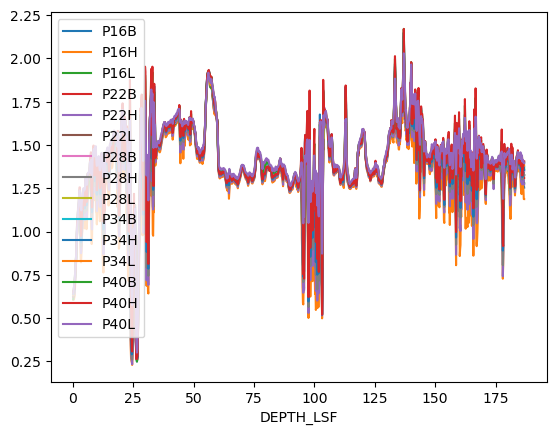

In [23]:
df.plot()

<Axes: xlabel='DEPTH_LSF'>

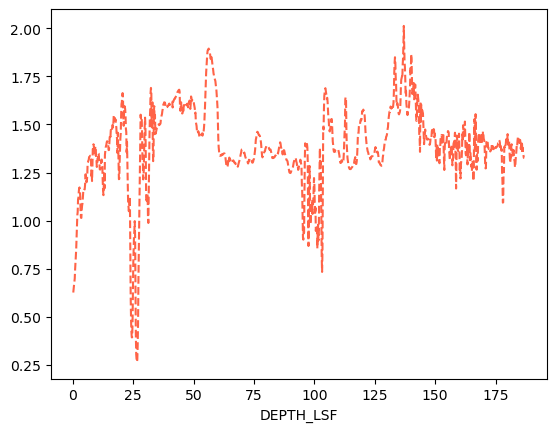

In [24]:
# You can also select only one variable to plot
df.loc[:, 'P22L'].plot(color='tomato', ls='--')

### Change the label of the index column with index.name

In [25]:
df.index.name = 'Depth'

In [26]:
df

,P16B,P16H,P16L,P22B,P22H,P22L,P28B,P28H,P28L,P34B,P34H,P34L,P40B,P40H,P40L
Depth,,,,,,,,,,,,,,,
0.1348,0.609138,0.606420,0.609138,0.625390,0.628182,0.625390,0.633311,0.642043,0.633311,0.635440,0.646374,0.635440,0.640069,0.650177,0.640069
0.2872,0.627580,0.606823,0.627579,0.646545,0.632340,0.646545,0.654598,0.649771,0.654598,0.654733,0.655505,0.654733,0.657815,0.659040,0.657815
0.4396,0.644199,0.610627,0.644199,0.663118,0.632921,0.663118,0.674138,0.650050,0.674138,0.678495,0.658393,0.678495,0.684064,0.664154,0.684064
0.5920,0.663892,0.619708,0.663892,0.681017,0.637017,0.681017,0.693011,0.653297,0.693011,0.699174,0.662530,0.699174,0.704357,0.666172,0.704357
0.7444,0.682845,0.630840,0.682845,0.697899,0.645322,0.697899,0.709838,0.659337,0.709838,0.717195,0.668764,0.717195,0.722439,0.674389,0.722439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186.2152,1.349504,1.321876,1.365414,1.367666,1.349495,1.378745,1.385877,1.375210,1.392777,1.399951,1.391715,1.405571,1.409557,1.401155,1.415531
186.3676,1.307980,1.264115,1.329541,1.327183,1.286108,1.349225,1.350870,1.316730,1.371008,1.374388,1.345850,1.392854,1.392158,1.364525,1.411478
186.5200,1.283353,1.242980,1.300715,1.326024,1.298547,1.340192,1.358904,1.344285,1.367395,1.381087,1.372510,1.386490,1.402996,1.395565,1.408120


## Dictionaries
So far we've worked with numpy arrays and pythin lists, but there is one important structure in Python that we havent discussed: dictionaries. This is an extremely useful data structure. It maps keys to values.

Dictionaries are unordered!

In [27]:
# Different ways to create disctionaries

# Using curly brackets-> key: value
band_facts = {'name': 'Coldplay', 'studio albums': 9}

# Usinf the function dict -> key=value
major_facts = dict(name='Geophysics', tracks=6)

print(type(band_facts))
print(band_facts)
print(type(major_facts))
print(major_facts)

<class 'dict'>
{'name': 'Coldplay', 'studio albums': 9}
<class 'dict'>
{'name': 'Geophysics', 'tracks': 6}


To access values in a dictionary, you can't use an index (because dictionaries are not ordered). You access values using their keys:

In [28]:
band_facts['name']

'Coldplay'

Square brackets [...] are Python for “get item” in many different contexts.

You can check for the presence of a key

In [29]:
# check if the dictionary major_facts has the key "tracks"
'tracks' in major_facts

True

In [30]:
# check if the dictionary major_facts has the key "students"
'students' in major_facts

False

If you try to access a key that doesn't exist in the dictionary, you will get an error:

In [31]:
# try to access a non-existant key
band_facts['grammys']

KeyError: 'grammys'

You can add new keys to a dictonary:

In [47]:
band_facts['grammys'] = 7
band_facts

{'name': 'Coldplay', 'studio albums': 9, 'grammys': 7}

A very useful trick is to iterate over keys:

In [48]:
# iterate over keys
for k in band_facts:
    print(k, band_facts[k])

name Coldplay
studio albums 9
grammys 7


We were talking about `pandas`, so why we've suddenly change to dictionaries? Well it turns out dictionaries are fundamental to DataFrames. Let's see how.

## Create DataFrames
### Creating DataFrames from Dictionaries

In [49]:
# first we create a dictionary
data = {'mass': [0.3e24, 4.87e24, 5.97e24],       # kg
        'diameter': [4879e3, 12_104e3, 12_756e3], # m
        'rotation_period': [1407.6, np.nan, 23.9] # h
       }
df = pd.DataFrame(data, index=['Mercury', 'Venus', 'Earth'])
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,NaN
Earth,5.970000e+24,12756000.0,23.9


Pandas handles missing data very elegantly, keeping track of it through all calculations

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 3 entries, Mercury to Earth
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mass             3 non-null      float64
 1   diameter         3 non-null      float64
 2   rotation_period  2 non-null      float64
dtypes: float64(3)
memory usage: 96.0+ bytes


As a recap, we can look at summary statistics using the `describe` method:

In [51]:
df.describe()

,mass,diameter,rotation_period
count,3.000000e+00,3.000000e+00,2.000000
mean,3.713333e+24,9.913000e+06,715.750000
std,3.006765e+24,4.371744e+06,978.423653
min,3.000000e+23,4.879000e+06,23.900000
25%,2.585000e+24,8.491500e+06,369.825000
50%,4.870000e+24,1.210400e+07,715.750000
75%,5.420000e+24,1.243000e+07,1061.675000
max,5.970000e+24,1.275600e+07,1407.600000


We can get a single column, which will return a Pandas Series, using python’s getitem syntax on the DataFrame object.

In [52]:
df['mass']

Mercury    3.000000e+23
Venus      4.870000e+24
Earth      5.970000e+24
Name: mass, dtype: float64

In [53]:
# A Series is a one-dimensional pandas object
type(df['mass'])

pandas.Series

We can also select a specific column using attribute ("dot") syntax.

In [54]:
df.mass

Mercury    3.000000e+23
Venus      4.870000e+24
Earth      5.970000e+24
Name: mass, dtype: float64

We've already seen that we can index using the operations `loc` and `iloc`.  

In [55]:
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,NaN
Earth,5.970000e+24,12756000.0,23.9


In [56]:
# Select the row "Earth" and comlun "mass"
df.loc['Earth', 'mass']

np.float64(5.97e+24)

### Merging, combining, and joining data

Pandas allow us to easly merge, combine, and manipulate DataFrames. Consider the dataframe below:

In [57]:
data = {'lead singer': ['Chris Martin', 'Freddie Mercury', 'Julian Casablancas'], 
        'albums': [9, 15, 6]
       }
df1 = pd.DataFrame(data, index=['Coldplay', 'Queen', 'The Strokes'])
df1

,lead singer,albums
Coldplay,Chris Martin,9
Queen,Freddie Mercury,15
The Strokes,Julian Casablancas,6


In [58]:
other_data = {'year created': [1997, 1970, 1998],      
        'grammys': [7, 0, 1]
       }
df2 = pd.DataFrame(other_data, index=['Coldplay', 'Queen', 'The Strokes'])
df2

,year created,grammys
Coldplay,1997,7
Queen,1970,0
The Strokes,1998,1


Now, we would like to merge the two Dataframes keeping the index (rows) and merging along the columns (axis=1). First we create a list with the DataFrames we want to "stick together"

In [59]:
dfs = [df1, df2]

Now we use the function `concat`, which stands for concatenate.

In [60]:
# We want to concatenate the DataFrames in the list "dfs" along the column axis (axis=1)
df_combined = pd.concat(dfs, axis=1)
df_combined

,lead singer,albums,year created,grammys
Coldplay,Chris Martin,9,1997,7
Queen,Freddie Mercury,15,1970,0
The Strokes,Julian Casablancas,6,1998,1


Now, let's suppose we have some more Coldplay facts.

In [61]:
more_facts = {'number of members': 4,      
        'hometown': 'London'  
       }
df3 = pd.DataFrame(more_facts, index=['Coldplay'])
df3

,number of members,hometown
Coldplay,4,London


Now, we still want to aggregate that to our main DataFrame, but the row index now only has "Coldplay". No problem! `pandas` will add the new fields to "Coldplay" and fill the rest with NaNs

In [62]:
df_all = pd.concat([df_combined, df3], axis=1)
df_all

,lead singer,albums,year created,grammys,number of members,hometown
Coldplay,Chris Martin,9,1997,7,4.0,London
Queen,Freddie Mercury,15,1970,0,NaN,NaN
The Strokes,Julian Casablancas,6,1998,1,NaN,NaN


### Saving your data

If you did quite a bit of manipulation on your raw data, it might be smart to save a processed version of it so you don't have to repeat all the steps in your code everytime. It is straighforward to save a `pandas` `DataFrame` to a text file, such as `csv`. The syntax is:

```python
df.to_csv('path/to/output/file_name.csv')
```

For example, the line below saves our DataFrame on the Desktop with the name "band_facts.csv".

In [63]:
df_all.to_csv('../data/band_facts.csv')

## Key Points
- Use the Pandas library to do statistics on tabular data; load CSV files with `pd.read_csv`.
- Use `DataFrame.set_index` to specify that a column's values should be used as row headings.
- Use `DataFrame.info` to find out more about a dataframe.
- The `DataFrame.columns` variable stores information about the dataframe's columns.
- Use `DataFrame.T` to transpose a dataframe.
- Use `DataFrame.describe` to get summary statistics about data.
- Use `DataFrame.iloc` to select values by position; use `DataFrame.loc` to select by label.
- `loc` slicing is inclusive at both ends; `iloc` slicing excludes the final index.
- Use Boolean masks to filter data; masked-out values become NaN and are ignored in calculations like `max`, `min`, and `mean`.
- Use `DataFrame.plot()` for quick data visualization during exploration.
- Python dictionaries map keys to values and are the foundation for creating DataFrames manually.
- Use `pd.concat` to combine multiple DataFrames along rows (`axis=0`) or columns (`axis=1`); missing values are filled with NaN.
- Save a DataFrame to CSV with `DataFrame.to_csv('path/to/file.csv')`.